### ENSIMAG – Grenoble INP – UGA - Academic year 2025-2026
# Introduction to Statistical Learning and Applications ([website](https://github.com/ISLA-Grenoble/2026-main))

- Pedro L. C. Rodrigues -- `pedro.rodrigues@inria.fr`

- Isabella Costa Maia -- `isabella.costa-maia@grenoble-inp.fr`

***

### ⚠️ General guidelines for TPs

Each team shall upload its report on [Teide](https://teide.ensimag.fr/) before the deadline indicated at the course website. Please
**include the name of all members** of the team on top of your report.
The report should contain graphical representations and explanatory text. For each graph, axis names should be provided as well
as a legend when it is appropriate. Figures should be explained by a few sentences in the text. Answer to
the questions in order and refer to the question number in your report. Computations and
graphics have to be performed in `python`. The report should be written as a jupyter notebook. This is a file format that allows users to format documents containing text written in markdown and `python` instructions. You should include all of the `python` instructions that you have used in the document so that it may be possible to replicate your results.

***

# 🖥️ TP1: Analysis of prostate cancer data

A medical study done on patients with prostate cancer aims to analyze the correlation between the prostate tumor volume and a set of clinical and morphometric variables. These variables include prostate specific antigens, a biomarker for prostate cancer, and a number of clinical measures (age, prostate weight, etc). The goal of this lab is to build a regression model to predict the severity of cancer, expressed by logarithm of the tumor volume -- `lcavol` variable -- from the following predictors:
- `lpsa`: log of a prostate specific antigen
- `lweight`: log of prostate weight
- `age`: age of the patient
- `lbph`: log of benign prostatic hyperplasia amount
- `svi`: seminal vesicle invasion
- `lcp`: log of capsular penetration
- `gleason`: Gleason score (score on a cancer prognosis test)
- `pgg45`: percent of Gleason scores 4 or 5

The file `prostate.data`, available [here](https://github.com/ISLA-Grenoble/2025-main/blob/main/TP/TP1/prostate.data), contains measures of the logarithm of the tumor
volume and of the 8 predictors for 97 patients. This file also contains an additional variable, called `train`, which will
not be used and has to be removed.

## ▶️ Exercise 1: Preliminary analysis of the data (1 points)

**(a)** Download the file `prostate.data` and store it in your current folder. Read the dataset in using `pandas` as per
```
import pandas as pd
df = pd.read_csv("prostate.data", sep="\t")
```
check how to use function `df.drop` to remove the first and last columns of `df` containing useless tags.

In [1]:
import pandas as pd
df = pd.read_csv("prostate.data", sep="\t")
df = df.drop(['Unnamed: 0', 'train'], axis=1)
df.head()

,lcavol,lweight,age,lbph,svi,lcp,gleason,pgg45,lpsa
0,-0.579818,2.769459,50,-1.386294,0,-1.386294,6,0,-0.430783
1,-0.994252,3.319626,58,-1.386294,0,-1.386294,6,0,-0.162519
2,-0.510826,2.691243,74,-1.386294,0,-1.386294,7,20,-0.162519
3,-1.203973,3.282789,58,-1.386294,0,-1.386294,6,0,-0.162519
4,0.751416,3.432373,62,-1.386294,0,-1.386294,6,0,0.371564


**(b)** The function defined below generates scatterplots (clouds of points) between all pairs of variables, allowing us to visually analyse the correlations between all variables in the dataframe. Explain what each line of function `pairplot` does and how it affects the final plot. You can use command `help` in the `python` shell to get the documentation of each function.

``` 
# import the main plotting library for python
import matplotlib.pyplot as plt

# make a pairplot from scratch
def pairplot(df, figsize=None):
    if figsize is None:
        figsize = (7.10, 6.70)
    n_vars = df.shape[1]
    fig, ax = plt.subplots(figsize=figsize, ncols=n_vars, nrows=n_vars)
    plt.subplots_adjust(
        wspace=0.10, hspace=0.10, left=0.05, right=0.95, bottom=0.05, top=0.95)
    for i in range(n_vars):
        for j in range(n_vars):
            axij = ax[i][j]
            i_name = df.columns[i]
            j_name = df.columns[j]
            axij.set_xticks([])
            axij.set_yticks([])
            axij.margins(0.1)
            if i != j:
                axij.scatter(df[i_name], df[j_name], s=10)
            else:
                axij.text(0.5, 0.5, i_name, fontsize=10,
                              horizontalalignment='center',
                              verticalalignment='center',
                              transform = axij.transAxes)        
    return fig, ax

fig, ax = pairplot(df)
plt.show()
```

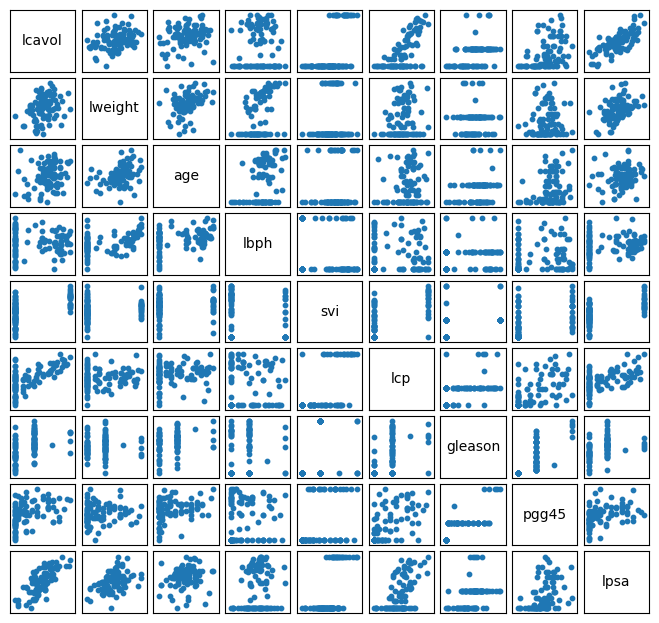

In [2]:
# import the main plotting library for python
import matplotlib.pyplot as plt

# make a pairplot from scratch
def pairplot(df, figsize=None):
    if figsize is None:
        figsize = (7.10, 6.70)
    n_vars = df.shape[1]
    fig, ax = plt.subplots(figsize=figsize, ncols=n_vars, nrows=n_vars)
    plt.subplots_adjust(
        wspace=0.10, hspace=0.10, left=0.05, right=0.95, bottom=0.05, top=0.95)
    for i in range(n_vars):
        for j in range(n_vars):
            axij = ax[i][j]
            i_name = df.columns[i]
            j_name = df.columns[j]
            axij.set_xticks([])
            axij.set_yticks([])
            axij.margins(0.1)
            if i != j:
                axij.scatter(df[i_name], df[j_name], s=10)
            else:
                axij.text(0.5, 0.5, i_name, fontsize=10,
                              horizontalalignment='center',
                              verticalalignment='center',
                              transform = axij.transAxes)        
    return fig, ax

fig, ax = pairplot(df)
plt.show()

<span style="color:blue">
<br>
    
### Explanation of pairplot's lines



- ```figsize = (7.10, 6.70)```
   -> Creates a figure of size (7.10, 6.70)

- ```n_vars = df.shape[1]```
  -> Gets the number of columns in the DataFrame
   -> get the number of columns of the DataFrame

- ```fig, ax = plt.subplots(figsize=figsize, ncols=n_vars, nrows=n_vars)```
   -> Cuts out the figure in squares of size n_vars $\times$ n_vars

- ```plt.subplots_adjust(wspace=0.10, hspace=0.10, left=0.05, right=0.95, bottom=0.05, top=0.95)``` 
    -> Used to make the figure clearer, adjusting margins and spacing

-  ```if i != j:```
                ```axij.scatter(df[i_name], df[j_name], s=10)```   
     -> If not on the diagonal :  generates a scatterplot between columns i and j of the DataFrame

- ```else: axij.text(0.5, 0.5, i_name, fontsize=10,horizontalalignment='center',verticalalignment='center', transform = axij.transAxes)```       -> If on the diagonal : print the name of the column in the center of the square
<br>
<span>

**(c)** Based on the generated figure, identify which variables seem the most correlated to `lcavol`. Also, infer the datatype for each of the predictors.

<span style="color:blue">
<br>
    
According to the generated figure, `lpsa` seems to be the variable the most correlated to lcavol. We could draw a line through the scatterplot, which means it is correlated. `lcp` could as well be quite correlated to lcavol, with the exception for a few points.  
<br>

<span>

In [3]:
print(df.dtypes)

lcavol     float64
lweight    float64
age          int64
lbph       float64
svi          int64
lcp        float64
gleason      int64
pgg45        int64
lpsa       float64
dtype: object


<span style="color:blue">

- `lcavol` : float64

- `lweight`: float64

- `age`: int64

- `lbph` : float64

- `svi` : int64

- `lcp` : float64

- `gleason` : int64

- `pgg45` : int64

- `lpsa` : float64

<span>

**(d)** Recall the formula of correlation between two vectors and implement it with `numpy`. Explain the difference of your result when compared to `df.corr()`. Change the function `pairplot`to show the correlation coefficient on the upper triangle of the subplots. (Bonus) Use locally weighted scatterplot smoothing (LOWESS) to see the trends between pairs of features with `statsmodels.nonparametric.smoothers_lowess`.

<span style="color:blue">
<br>    

For X, Y two vectors, we use Pearson's correlation formula ([source](https://en.wikipedia.org/wiki/Pearson_correlation_coefficient)) :
<br>
$$ \boxed{\quad \rho_{XY} \quad  = \quad \frac{Cov[XY]}{\sigma_X \sigma_Y} \quad} $$
<br>
<span>

In [4]:
import numpy as np

def isCorrelated(X, Y) :
    # Mcov is the matrix of covariance
    Mcov = np.cov(X, Y)

    if Mcov[0][0] == 0 and Mcov[1][1] == 0 :
        print("Var[X] = 0 and Var[Y] = 0")
        return

    sigX = np.sqrt(Mcov[0][0])
    sigY = np.sqrt(Mcov[1][1])
    cov = Mcov[0][1]

    # Using round(_, 6) to do as well as df.corr()
    return round(cov/(sigX*sigY), 6)

In [5]:
def dataCorr(df) :
    n_vars = df.shape[1]
    for i in range(n_vars):
        i_name = df.columns[i]
        print(i_name)
        for j in range(n_vars):
            j_name = df.columns[j]
            print(j_name, isCorrelated(df[i_name], df[j_name]))
        print("\n")

dataCorr(df)

lcavol
lcavol 1.0
lweight 0.280521
age 0.225
lbph 0.02735
svi 0.538845
lcp 0.67531
gleason 0.432417
pgg45 0.433652
lpsa 0.73446


lweight
lcavol 0.280521
lweight 1.0
age 0.347969
lbph 0.442264
svi 0.155385
lcp 0.164537
gleason 0.056882
pgg45 0.107354
lpsa 0.433319


age
lcavol 0.225
lweight 0.347969
age 1.0
lbph 0.350186
svi 0.117658
lcp 0.127668
gleason 0.268892
pgg45 0.276112
lpsa 0.169593


lbph
lcavol 0.02735
lweight 0.442264
age 0.350186
lbph 1.0
svi -0.085843
lcp -0.006999
gleason 0.07782
pgg45 0.07846
lpsa 0.179809


svi
lcavol 0.538845
lweight 0.155385
age 0.117658
lbph -0.085843
svi 1.0
lcp 0.673111
gleason 0.320412
pgg45 0.457648
lpsa 0.566218


lcp
lcavol 0.67531
lweight 0.164537
age 0.127668
lbph -0.006999
svi 0.673111
lcp 1.0
gleason 0.51483
pgg45 0.631528
lpsa 0.548813


gleason
lcavol 0.432417
lweight 0.056882
age 0.268892
lbph 0.07782
svi 0.320412
lcp 0.51483
gleason 1.0
pgg45 0.751905
lpsa 0.368987


pgg45
lcavol 0.433652
lweight 0.107354
age 0.276112
lbph 0.07846
svi 

In [6]:
print(df.corr())

           lcavol   lweight       age      lbph       svi       lcp   gleason  \
lcavol   1.000000  0.280521  0.225000  0.027350  0.538845  0.675310  0.432417   
lweight  0.280521  1.000000  0.347969  0.442264  0.155385  0.164537  0.056882   
age      0.225000  0.347969  1.000000  0.350186  0.117658  0.127668  0.268892   
lbph     0.027350  0.442264  0.350186  1.000000 -0.085843 -0.006999  0.077820   
svi      0.538845  0.155385  0.117658 -0.085843  1.000000  0.673111  0.320412   
lcp      0.675310  0.164537  0.127668 -0.006999  0.673111  1.000000  0.514830   
gleason  0.432417  0.056882  0.268892  0.077820  0.320412  0.514830  1.000000   
pgg45    0.433652  0.107354  0.276112  0.078460  0.457648  0.631528  0.751905   
lpsa     0.734460  0.433319  0.169593  0.179809  0.566218  0.548813  0.368987   

            pgg45      lpsa  
lcavol   0.433652  0.734460  
lweight  0.107354  0.433319  
age      0.276112  0.169593  
lbph     0.078460  0.179809  
svi      0.457648  0.566218  
lcp      

<span style="color:blue">
<br>
    
The `dataCorr` fonction presents very similar results as method `corr`. The difference lies in the rounding of rho's value.

<br>
<span>

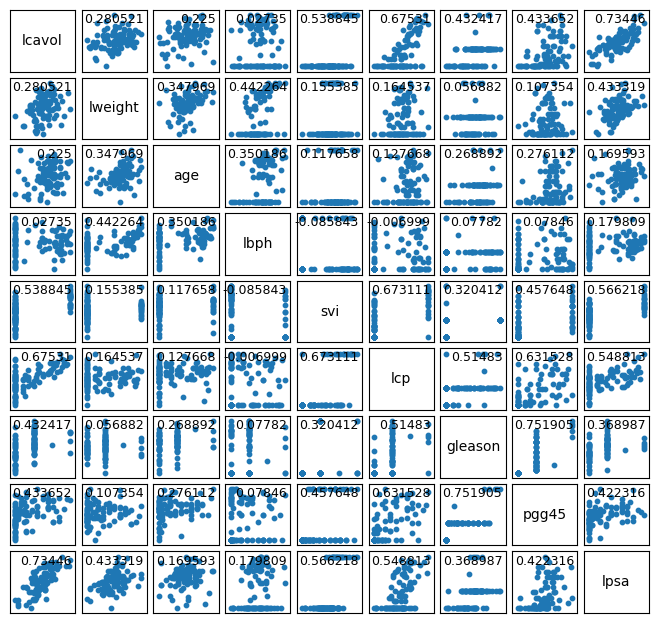

In [7]:
# make a pairplot from scratch
def pairplotCorr(df, figsize=None):
    if figsize is None:
        figsize = (7.10, 6.70)
    n_vars = df.shape[1]
    fig, ax = plt.subplots(figsize=figsize, ncols=n_vars, nrows=n_vars)
    plt.subplots_adjust(
        wspace=0.10, hspace=0.10, left=0.05, right=0.95, bottom=0.05, top=0.95)
    for i in range(n_vars):
        for j in range(n_vars):
            axij = ax[i][j]
            i_name = df.columns[i]
            j_name = df.columns[j]
            axij.set_xticks([])
            axij.set_yticks([])
            axij.margins(0.1)
            if i != j:
                axij.scatter(df[i_name], df[j_name], s=10)
                # We add the correlation coefficient on the upper right of each figure
                corr = isCorrelated(df[i_name], df[j_name])
                axij.text(0.95, 0.95, f"{corr}", fontsize=9,
                              horizontalalignment='right',
                              verticalalignment='top',
                              transform=axij.transAxes)  
            else:
                axij.text(0.5, 0.5, i_name, fontsize=10,
                              horizontalalignment='center',
                              verticalalignment='center',
                              transform = axij.transAxes)        
    return fig, ax

fig, ax = pairplotCorr(df)
plt.show()

## ▶️ Exercise 2: Linear regression (7 points)

In this exercise, we will perform a multiple linear regression to build a predictive model for the `lcavol` variable. The variables `gleason` and `svi` should be considered as qualitative variables. You can declare them as such with

```
df['svi'] = df['svi'].astype("category")
df['gleason'] = df['gleason'].astype("category")
```

**(a)** Provide the mathematical equation of the regression model (note that you can use LaTeX to write equations) and define the diﬀerent parameters. 

In [8]:
df['svi'] = df['svi'].astype("category")
df['gleason'] = df['gleason'].astype("category")

<span style="color:blue">
<br>
    
As `gleason` and `svi` are qualitative variables, we have to use dummy variables to encode categories. Let's check which are the values `gleason` and `svi` can take.
    
<br>
<span>

In [61]:
gleason = df["gleason"]
gleasonList = []
for x in gleason :
    if x not in gleasonList :
        gleasonList.append(x)

svi = df["svi"]
sviList = []
for x in svi :
    if x not in sviList :
        sviList.append(x)

print("List of values of gleason : ", gleasonList)
print("List of values of svi : ", sviList, "\n")

List of values of gleason :  [6, 7, 8, 9]
List of values of svi :  [0, 1] 



In [10]:
print(df.columns)

Index(['lcavol', 'lweight', 'age', 'lbph', 'svi', 'lcp', 'gleason', 'pgg45',
       'lpsa'],
      dtype='str')


<span style="color:blue">
<br>
    
As we showed, `svi` is binary, while `gleason` can take 4 different values. We only need $K-1$ dummy variables for $K$ possible values. Hence, we get the equation :

<br>


$$\boxed{ \quad Y_{\text{lcavol}}\quad = \quad \beta_0 \quad +  \quad \beta_1 X_{\text{lweight}} \quad + \quad \beta_2 X_{\text{age}} \quad + \quad \beta_3 X_{\text{lbph}} \quad + \quad \beta_4 X_{\text{lcp}} \quad + \quad \beta_5 X_{\text{pgg45}} \quad + \quad \beta_6 X_{\text{lpsa}} \quad + \quad \gamma X_{\text{svi dummy}} \quad + \quad \sum_{i=1}^3 \lambda_i X_{\text{gleason dummy i}} \quad + \quad \epsilon \quad}$$

<br>

Having $Y_{\text{lcavol}}$ being the representative vector for the lcavol variable and the $X$ variables representative of the other vectors, with $\epsilon \sim \texttt{N}(0, \sigma ^2)$ 

<br>
<br>
<span>

**(b)** Before doing the linear regression of this TP, you will first have to handle the one-hot encoding of the categorical features of the dataframe. One way of doing this is as follows:

```
# encode the categorical features with dummy variables
df_enc = pd.get_dummies(df, dtype=np.float64)
# to drop one dummy column for each predictor
df_enc = df_enc.drop(columns=['svi_0', 'gleason_6'])
# add a column of ones to the dataframe
df_enc['intercept'] = 1
# extract the dataframe for predictors
X = df_enc.drop(columns=['lcavol'])
# get the observed values to predict
y = df['lcavol']
```

- Why did we fix a `dtype` in `pd.get_dummies`?
- Why did we drop two columns after the encoding?
- Why did we add a column of ones to the dataframe?

In [11]:
# encode the categorical features with dummy variables
df_enc = pd.get_dummies(df, dtype=np.float64)
# to drop one dummy column for each predictor
df_enc = df_enc.drop(columns=['svi_0', 'gleason_6'])
# add a column of ones to the dataframe
df_enc['intercept'] = 1
# extract the dataframe for predictors
X = df_enc.drop(columns=['lcavol'])
# get the observed values to predict
y = df['lcavol']
df_enc.head()

,lcavol,lweight,age,lbph,lcp,pgg45,lpsa,svi_1,gleason_7,gleason_8,gleason_9,intercept
0,-0.579818,2.769459,50,-1.386294,-1.386294,0,-0.430783,0.0,0.0,0.0,0.0,1
1,-0.994252,3.319626,58,-1.386294,-1.386294,0,-0.162519,0.0,0.0,0.0,0.0,1
2,-0.510826,2.691243,74,-1.386294,-1.386294,20,-0.162519,0.0,1.0,0.0,0.0,1
3,-1.203973,3.282789,58,-1.386294,-1.386294,0,-0.162519,0.0,0.0,0.0,0.0,1
4,0.751416,3.432373,62,-1.386294,-1.386294,0,0.371564,0.0,0.0,0.0,0.0,1


**(c)** We will use the [`statsmodels`](https://www.statsmodels.org/) package to estimate the coefficients of the multiple linear regression as per:

```
# import required package
import statsmodels.api as sm
# this line does not fit the regression model per se but only builds it
model = sm.OLS(y, X)
# now we actually fit the model, e.g. calculate all of regression parameters
results = model.fit()
```

Use command `results.summary()` to get the statistical summary of the estimated coefficients. 

- Explain to what correspond the regression coeﬃcients for the lines related to `svi` and `gleason`. 

- What would have happened in the regression if we did not do the one-hot encoding from above?

- Comment the overall results of the regression as well.

In [12]:
# import required package
import statsmodels.api as sm
# this line does not fit the regression model per se but only builds it
model = sm.OLS(y, X)
# now we actually fit the model, e.g. calculate all of regression parameters
results = model.fit()

In [13]:
results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                 lcavol   R-squared:                       0.686
Model:                            OLS   Adj. R-squared:                  0.650
Method:                 Least Squares   F-statistic:                     18.83
Date:                Mon, 23 Feb 2026   Prob (F-statistic):           9.05e-18
Time:                        13:10:33   Log-Likelihood:                -96.825
No. Observations:                  97   AIC:                             215.7
Df Residuals:                      86   BIC:                             244.0
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
lweight       -0.0112      0.211     -0.053      0.958      -0.432       0.409
age            0.0248      0.011      2.205      0.030       0.002       0.047
lbph          -0.1042      0.058     -1.790      0.077      -0.220       0.012
lcp            0.4028      0.085      4.734      0.000       0.234       0.572
pgg45         -0.0094      0.005     -2.080      0.040      -0.018      -0.000
lpsa           0.5496      0.090      6.100      0.000       0.370       0.729
svi_1         -0.2204      0.256     -0.860      0.392      -0.730       0.289
gleason_7      0.3117      0.215      1.448      0.151      -0.116       0.740
gleason_8     -0.7106      0.759     -0.936      0.352      -2.219       0.798
gleason_9      0.7901      0.488      1.621      0.109      -0.179       1.759
intercept     -1.4067      0.874     -1.609      0.111      -3.145       0.332
==============================================================================
Omnibus:                        0.107   Durbin-Watson:                   2.306
Prob(Omnibus):                  0.948   Jarque-Bera (JB):                0.127
Skew:                          -0.073   Prob(JB):                        0.939
Kurtosis:                       2.900   Cond. No.                         884.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

<span style="color:blue">
<br>

- The coefficient for svi_1 is approximately $-0.22$, meaning that those with a `svi` of 1 seem to have a $0.22$ lower value of `lcavol` compared to patients with a `svi` of $0$. However, the p-value equals $0.392$, meaning that the statistic is not statistically significant. We could conclude that `svi` is not statistically significant for `lcavol`.

<br>

- For the same reasons, `gleason` is not statistically significant because its p-values are too high. Notice that gleason_9 could be considered because of its p-value. In contrast, `lcp` and `lpsa` are highly significant predictors of `lcavol` (positive coefficient with a p-value of $0.0$).

<br>

- If we had not done the one-hot encoding, the regression would have implied a linear correlation between `lcavol` and `gleason` for instance. It means that moving from 6 to 7 would have the same effect as to move from 8 to 9, which may be incorrect or unrealistic.

<br>

- We are looking for variables with a p-value under $0.05$ to be statistically significant with `lcavol`. The variables that are good predictors for `lcavol` are :
<br>

$$\boxed{\quad \text{age} \quad \quad \text{lcp} \quad \quad \text{pgg45} \quad \quad \text{lpsa} \quad}$$

<br>

Notice that `lcp` and `lpsa` are the best predictors for `lcavol`, which corresponds to exercise 1, question c).

<br>
<br>
<span>

**(d)** Use `results.conf_int` to get confidence intervals of level 95% for all the coeﬃcients of the predictors. Comment the results.

In [14]:
results.conf_int()

,0,1
lweight,-0.431600,0.409107
age,0.002436,0.047129
lbph,-0.219914,0.011515
lcp,0.233639,0.571880
pgg45,-0.018469,-0.000419
lpsa,0.370474,0.728673
svi_1,-0.730029,0.289190
gleason_7,-0.116263,0.739616
gleason_8,-2.219087,0.797911
gleason_9,-0.179004,1.759273


<span style="color:blue">
<br>

As mentioned above, the statistically significant predictors of `lcavol` are the `age`, `pgg45`, `lcp` and `lpsa`. Considering the method *conf_int*, we can be confident that the `age` and `pgg45` significant with `lcavol`, but their confidence intervall are close to zero. However, we can be confident at $95$% that `lcp` is associated with an increase in `lcavol` between $0.23$ and $0.57$, while it is between $0.37$ and $0.73$ for `lpsa`.

<br>
<br>
<span>

**(e)** What can you say about the eﬀects of the `lpsa` variable? Relate your answer to the $p$-value of a hypothesis test and a confidence interval. You can use `results.pvalues`.

In [15]:
results.pvalues

lweight      9.577075e-01
age          3.014993e-02
lbph         7.695609e-02
lcp          8.577858e-06
pgg45        4.047741e-02
lpsa         2.939241e-08
svi_1        3.922717e-01
gleason_7    1.512950e-01
gleason_8    3.516744e-01
gleason_9    1.087313e-01
intercept    1.113676e-01
dtype: float64

<span style="color:blue">
<br>

The variable `lpsa` has an estimated coefficient of $0.55$, indicating that `lpsa`, holding other variables constant, is associated with an average increase in `lcavol` of $0.55$. The p-value is very small, meaning `lpsa` is a statistically significant predictor of `lcavol`. Moreover, its confidence interval at the $95$%  shows as well it is a statistically significant predictor of `lcavol`.

<br>
<span>

**(f)** Implement yourself a function that calculates the values of the parameters and their corresponding $p$-values. Bonus: explain why `numpy.linalg.inv` is not necessarily the best choice for estimating the parameters as compared to `numpy.linalg.solve`.

<span style="color:blue">
<br>

According to CM2, $n$ being the number of observations and $p$ the number of parameters of $X$ we have :

$$\hat\beta \quad = \quad (X^{T}X)^{-1}X^{T}Y$$

$$ \hat\sigma^2 \quad = \quad \frac{1}{n-p} ||Y - X\hat\beta||^2 $$

$$ \hat{\text{se}}[\hat\beta_i] \quad = \quad \sqrt{\hat\sigma^2(X^TX)_{i+1, i+1}^{-1}} $$

$$ \frac{\hat\beta_i}{\hat{\text{se}}[\hat\beta_i]} \sim t_{n-p-1} $$

<br>

To compute the p-value, I used : [Stackoverflow](https://stackoverflow.com/questions/17559897/python-p-value-from-t-statistic)

<br>
<span>

In [16]:
from scipy import stats 
def pvalue(X, Y):
    n, p = X.shape

    # beta hat, using numpy.linalg.solve, without inversing X^TX
    beta_hat = np.linalg.solve(X.transpose().dot(X), X.transpose().dot(Y))

    # sigma hat square
    Y_XB = Y - X.dot(beta_hat)
    sigma_hat_square = (Y_XB.transpose().dot(Y_XB))/(n-p)

    # se[beta]
    var_beta = sigma_hat_square * (np.linalg.inv(X.transpose().dot(X)))
    se_beta = np.sqrt(np.diag(var_beta))

    # t
    t = beta_hat/se_beta

    # p-value
    pval = stats.t.sf(np.abs(t), n-p)*2

    return beta_hat, sigma_hat_square, t, pval

In [17]:
beta_hat, sigma_hat_square, t, pval = pvalue(X, y)
print("beta_hat = ", beta_hat, "\n")
print("sigma_hat_square = ", sigma_hat_square, "\n")
print("t = ", t, "\n")
print("pval = ", pval, "\n")

beta_hat =  [-0.0112462   0.02478241 -0.10419954  0.40275962 -0.00944383  0.5495731
 -0.22041936  0.31167619 -0.71058822  0.79013455 -1.40665404] 

sigma_hat_square =  0.48621010009355053 

t =  [-0.05318546  2.20462818 -1.79010738  4.73425167 -2.08026309  6.10004718
 -0.85983297  1.44784956 -0.93642928  1.62075494 -1.60860639] 

pval =  [9.57707489e-01 3.01499280e-02 7.69560879e-02 8.57785824e-06
 4.04774068e-02 2.93924065e-08 3.92271694e-01 1.51294991e-01
 3.51674448e-01 1.08731299e-01 1.11367559e-01] 



<span style="color:blue">
<br>

Notice that we get the same values as when we used the OLS method of statsmodel.

<br>
<span>

**(g)** Plot the predicted values of `lcavol` as a function of the actual values. For this, you can can use `results.get_prediction` to get predictions over `X` and then get its `predicted_mean` attribute.

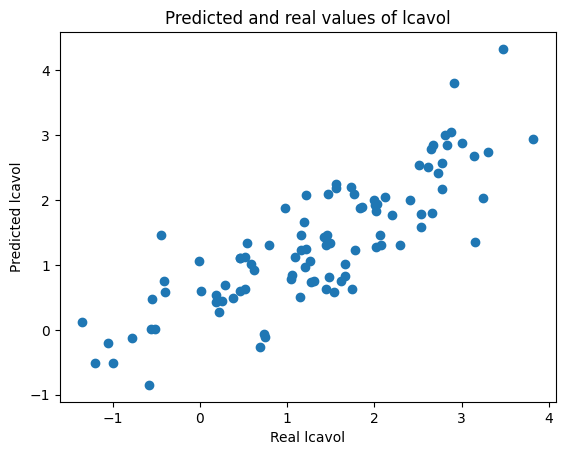

In [18]:
import matplotlib.pyplot as plt

preds = results.get_prediction(X)
preds_y = preds.predicted_mean

plt.scatter(y, preds_y)
plt.xlabel("Real lcavol")
plt.ylabel("Predicted lcavol")
plt.title("Predicted and real values of lcavol")
plt.show()

**(h)** Plot the histogram of residuals as well as their qq-plot using statsmodels function `qqplot`. Can we admit that the residuals are normally distributed? Compute the residual sum of squares (RSS).

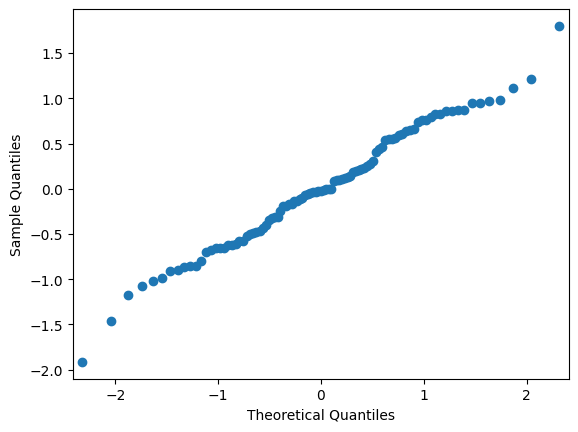

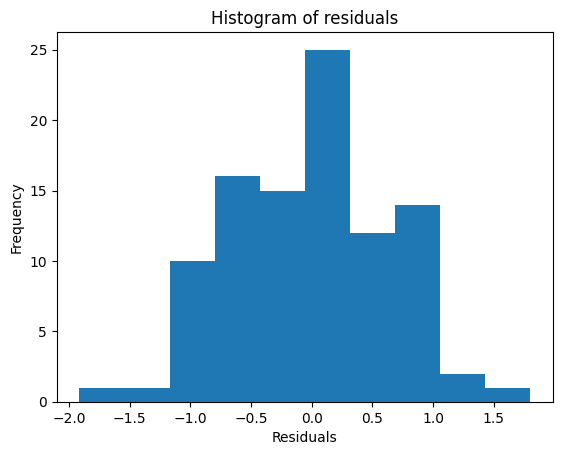

In [19]:
# Residuals
res = results.resid
fig = sm.qqplot(res)

# There are two graphics to plot
plt.figure()
plt.hist(res)
plt.xlabel("Residuals")
plt.ylabel("Frequency")
plt.title("Histogram of residuals")
plt.show()

<span style="color:blue">
<br>

According to the graphics, the distribution seems to be normal. However, we can raise a doubt due to the tail and head of the distribution.

The RSS is computed with the formula :

$$ \text{RSS} \quad = \quad \sum (y_i - \hat y_i)^2 $$

<br>
<span>

In [20]:
def RSScompute(y, preds_y) :
    # Using round to avoid getting to much decimals
    return round(np.sum((y-preds_y)**2), 2)

In [21]:
print(RSScompute(y, preds_y))

41.81


<span style="color:blue">
<br>

Thus, we get :

$$\boxed{ \quad \text{RSS} \quad = \quad 41.81 \quad }$$

<br>
<span>

**(i)** What happens if predictors `lpsa` and `lcp` are removed from the multiple linear regression model? Note that you can pass a list of strings to `df.columns.drop` method.

In [22]:
# extract the dataframe for predictors
X_adapted = df_enc.drop(columns=['lpsa', 'lcp', 'lcavol'])
model_adapted = sm.OLS(y, X_adapted)
# now we actually fit the model, e.g. calculate all of regression parameters
results_adapted = model_adapted.fit()

In [23]:
results_adapted.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                 lcavol   R-squared:                       0.433
Model:                            OLS   Adj. R-squared:                  0.381
Method:                 Least Squares   F-statistic:                     8.390
Date:                Mon, 23 Feb 2026   Prob (F-statistic):           2.11e-08
Time:                        13:10:34   Log-Likelihood:                -125.58
No. Observations:                  97   AIC:                             269.2
Df Residuals:                      88   BIC:                             292.3
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
lweight        0.5850      0.259      2.257      0.026       0.070       1.100
age            0.0073      0.015      0.497      0.621      -0.022       0.036
lbph          -0.0746      0.077     -0.967      0.336      -0.228       0.079
pgg45         -0.0004      0.006     -0.076      0.939      -0.012       0.011
svi_1          1.0246      0.271      3.774      0.000       0.485       1.564
gleason_7      0.8007      0.274      2.918      0.004       0.255       1.346
gleason_8      0.6869      0.960      0.715      0.476      -1.221       2.595
gleason_9      1.1726      0.644      1.820      0.072      -0.108       2.453
intercept     -1.9717      1.159     -1.701      0.092      -4.275       0.332
==============================================================================
Omnibus:                        0.297   Durbin-Watson:                   1.949
Prob(Omnibus):                  0.862   Jarque-Bera (JB):                0.473
Skew:                          -0.013   Prob(JB):                        0.789
Kurtosis:                       2.659   Cond. No.                         882.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

<span style="color:blue">
<br>

According to the summary, removing `lpsa` and `lcp` leads to `lweight`, `svi_1`, `gleason_7` and `gleason_9` being statistically significant predictors of `lcavol`.

Notice that the `age` and `pgg45` are not statistically significant predictors anymore.

<br>
<span>

## ▶️ Exercise 3: Best subset selection (5 points)

A regression model that uses $k$ predictors is said to be of size $k$. For instance, 

$$
\texttt{lcavol} = \beta_1 \texttt{lpsa} + \beta_0 + \varepsilon \quad \text{and} \quad \texttt{lcavol} = \beta_1 \texttt{lweight} + \beta_0 + \varepsilon
$$

are models of size one. The regression model without any predictor $\texttt{lcavol} = \beta_0 + \varepsilon$ is a model of size 0.

The goal of this exercise is to select the best model of size $k$ for each $k \in \{0, \dots, 8\}$.

**(a)** Compute the residual sums of squares (RSS) for all models of size $k = 2$. Which model has the smallest RSS? Note that you can use a generator [`itertools.combination`](https://docs.python.org/3/library/itertools.html#itertools.combinations) to automatize for you all the combinations of $k$ elements among $n$.

In [24]:
print(df.columns)

Index(['lcavol', 'lweight', 'age', 'lbph', 'svi', 'lcp', 'gleason', 'pgg45',
       'lpsa'],
      dtype='str')


In [25]:
from itertools import combinations

# We get the columns except for lcavol
columns = df.columns[1:]
quant_columns = ['lweight', 'age', 'lbph', 'lcp', 'pgg45', 'lpsa']

def compute_RSS_2() :
    best_predictors = ("", "")
    best_RSS = 10000
    # generate all combinations of length 2
    for couple in combinations(columns, 2):
        columns_to_drop = ["lcavol"]
        if "svi" not in couple :
            columns_to_drop.append("svi_1")
        if "gleason" not in couple :
            columns_to_drop.extend(["gleason_7", "gleason_8", "gleason_9"])
            
        for x in quant_columns :
            if x not in couple :
                columns_to_drop.append(f"{x}")

        X = df_enc.drop(columns=columns_to_drop)

        model = sm.OLS(y, X)
        results = model.fit()

        preds_y = results.get_prediction(X).predicted_mean

        RSS = np.sum((y-preds_y)**2)

        # We get the best RSS and predictors
        if RSS < best_RSS :
            best_RSS = RSS
            best_predictors = couple

        print("Predictors : ", couple[0], couple[1], "             ", " RSS = ", round(RSS, 2))
        
    print("\n")
    print("The minimal RSS equals : ", round(best_RSS, 2), " and is reached with ", best_predictors)

In [26]:
compute_RSS_2()

Predictors :  lweight age                RSS =  120.4
Predictors :  lweight lbph                RSS =  121.31
Predictors :  lweight svi                RSS =  89.35
Predictors :  lweight lcp                RSS =  68.61
Predictors :  lweight gleason                RSS =  92.16
Predictors :  lweight pgg45                RSS =  100.9
Predictors :  lweight lpsa                RSS =  61.19
Predictors :  age lbph                RSS =  126.21
Predictors :  age svi                RSS =  91.11
Predictors :  age lcp                RSS =  69.93
Predictors :  age gleason                RSS =  97.85
Predictors :  age pgg45                RSS =  106.68
Predictors :  age lpsa                RSS =  60.04
Predictors :  lbph svi                RSS =  93.91
Predictors :  lbph lcp                RSS =  72.4
Predictors :  lbph gleason                RSS =  98.72
Predictors :  lbph pgg45                RSS =  108.27
Predictors :  lbph lpsa                RSS =  59.91
Predictors :  svi lcp                RSS 

<span style="color:blue">
<br>

This result is not surprising, as we saw `lcp` and `lpsa` were the most statistically significant predictors of `lcavol`.

<br>
<span>

**(b)** For each value of $k \in \{0, \dots, 8\}$, select the set of predictors that minimizes the RSS. Plot these values as a function of $k$. Provide the names of the selected predictors for each value of $k$.

In [27]:
def compute_RSS_k(k) :
    best_predictors = None
    best_RSS = float("inf")
    # generate all combinations of length k
    for vector in combinations(columns, k):
        columns_to_drop = ["lcavol"]
        if "svi" not in vector :
            columns_to_drop.append("svi_1")
        if "gleason" not in vector :
            columns_to_drop.extend(["gleason_7", "gleason_8", "gleason_9"])
            
        for x in quant_columns :
            if x not in vector :
                columns_to_drop.append(f"{x}")

        X = df_enc.drop(columns=columns_to_drop)

        model = sm.OLS(y, X)
        results = model.fit()

        preds_y = results.get_prediction(X).predicted_mean

        RSS = np.sum((y-preds_y)**2)

        # We get the best RSS and predictors
        if RSS < best_RSS :
            best_RSS = RSS
            best_predictors = vector

    return best_predictors, best_RSS

In [28]:
def get_best_RSS() :
    best_predictors = []
    best_RSS = []
    k = 9

    for i in range(k):
        predictors, RSS =  compute_RSS_k(i)
        best_predictors.append(predictors)
        best_RSS.append(round(RSS, 2))

    return best_predictors, best_RSS

In [29]:
# We greed to get the best RSS for each k, so we won't try to use again the fonction get_best_RSS
best_predictors, best_RSS = get_best_RSS()
print(best_predictors, "\n")
print(best_RSS)

[(), ('lpsa',), ('lcp', 'lpsa'), ('age', 'lcp', 'lpsa'), ('age', 'lbph', 'lcp', 'lpsa'), ('age', 'lcp', 'gleason', 'pgg45', 'lpsa'), ('age', 'lbph', 'lcp', 'gleason', 'pgg45', 'lpsa'), ('age', 'lbph', 'svi', 'lcp', 'gleason', 'pgg45', 'lpsa'), ('lweight', 'age', 'lbph', 'svi', 'lcp', 'gleason', 'pgg45', 'lpsa')] 

[np.float64(133.36), np.float64(61.42), np.float64(47.28), np.float64(46.24), np.float64(44.88), np.float64(43.69), np.float64(42.17), np.float64(41.82), np.float64(41.81)]


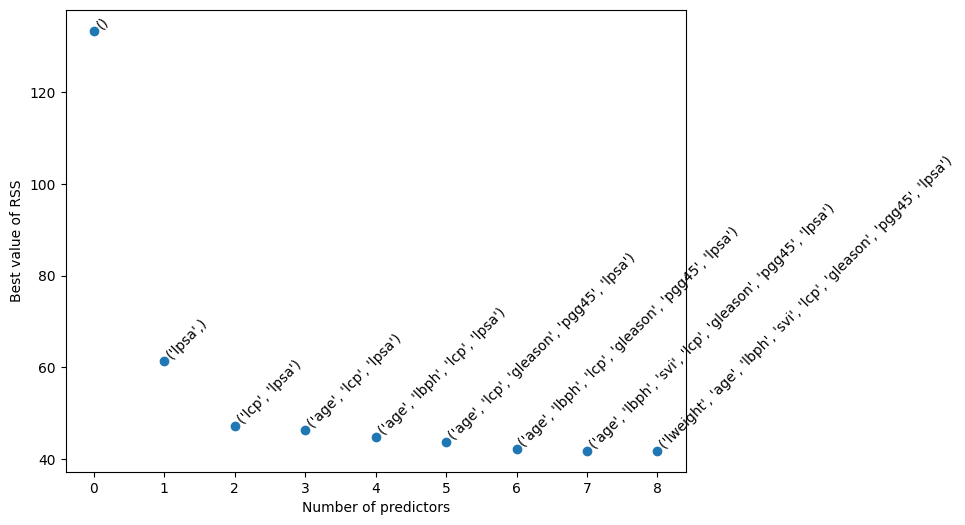

In [30]:
k = [i for i in range(9)]
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(k, best_RSS)

# a label above each point
for i in range(len(k)):
    ax.annotate(f"{best_predictors[i]}", (k[i], best_RSS[i]+0.5), rotation=45)  

plt.xlabel("Number of predictors")
plt.ylabel("Best value of RSS")
plt.show()

**(c)** Do you think that minimizing the residual sum of squares is well suited to select the optimal size for the regression models? Justify your answer using what you've learned in class.

<span style="color:blue">
<br>

We observe that increasing the number of predictors reduce the RSS value. Thus, we can be tempted to minimize the RSS by including as many predictors as possible, which is not a good strategy. The model will indeed become too complex and may overfit the data.

<br>
<span>

## ▶️ Exercise 4: Split-validation (5 points)

You have now found the best model for each of the nine possible model sizes. In the following, we wish to compare these nine diﬀerent regression models.

**(a)** Give a brief overview of split-validation: how it works? Why it is not subject to the same issues raised in
the item (c) of the previous Exercise?

<span style="color:blue">
<br>

The idea of split-validation is to divide the original dataset into 2 subsets : a training set and a test set. The goal is to train the model on the training set and then evaluate its performance on the test set. We compare different models (for instance, with different combinations of predictors) and select the one that minimize the loss on the test set.

Contrary to the previous exercice, split-validation evaluates the model's performance on data that were not used during the training phase. Thus, it allows to detect whether the model is overfitting the training data. 

<br>
<span>

**(b)** Use function `train_test_split` from the `sklearn` package to split the dataset into a training and a validation (or test) partition. You can set `test_size=0.3`. For each of the nine models from before (i.e. those that minimized the RSS for each size $k$), compute the mean prediction error calculated over the samples from the test set and compare it to its corresponding mean training error. Plot a curve for each of these error as a function of size $k$. 

In [31]:
from sklearn.model_selection import train_test_split

def computeMPE(best_predictors):
    MPE_list = []
    MTE_list = []
    n = len(best_predictors)
    X_full = df_enc.drop(columns=["lcavol"])
    
    # split-validation
    X_full_train, X_full_test, y_train, y_test = train_test_split(X_full, y, test_size=0.3, random_state=42)
    

    for i in range(n):
        columns_to_drop = []
        if "svi" not in best_predictors[i] :
            columns_to_drop.append("svi_1")
        if "gleason" not in best_predictors[i] :
            columns_to_drop.extend(["gleason_7", "gleason_8", "gleason_9"])
            
        for x in quant_columns :
            if x not in best_predictors[i] :
                columns_to_drop.append(f"{x}")

        X_train = X_full_train.drop(columns=columns_to_drop)
        X_test = X_full_test.drop(columns=columns_to_drop)


        model = sm.OLS(y_train, X_train)
        results = model.fit()

        preds_y_train = results.get_prediction(X_train).predicted_mean
        preds_y_test = results.get_prediction(X_test).predicted_mean

        MTE_list.append(np.mean((y_train - preds_y_train)**2))
        MPE_list.append(np.mean((y_test - preds_y_test)**2))

    return MTE_list, MPE_list

In [32]:
MTE_list, MPE_list = computeMPE(best_predictors)

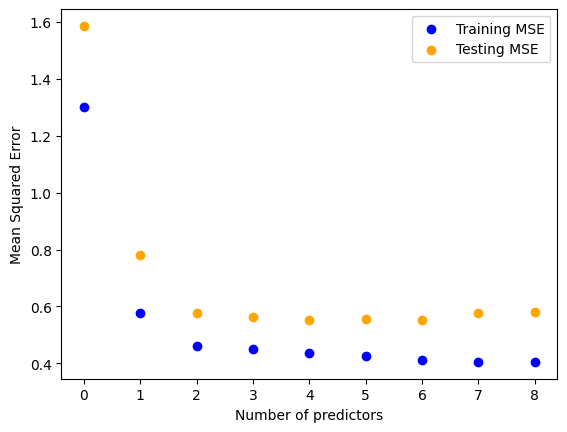

In [33]:
k = [i for i in range(9)]

plt.scatter(k, MTE_list, color="blue", label="Training MSE")
plt.scatter(k, MPE_list, color="orange", label="Testing MSE")
plt.xlabel("Number of predictors")
plt.ylabel("Mean Squared Error")
plt.legend()
plt.show()

In [34]:
print(np.argmin(MPE_list))
print(MPE_list)

6
[np.float64(1.5853556184408277), np.float64(0.7812324440369813), np.float64(0.5754303217408926), np.float64(0.563736405545609), np.float64(0.552333951011405), np.float64(0.5564347700550578), np.float64(0.5516360672443601), np.float64(0.5765468305392392), np.float64(0.5789284009126142)]


<span style="color:blue">
<br>

We observe that the mean squared error value is higher on the test set than on the training set. This indicates that the model fits the training data better than the test data. It might mean the model is overfitting.

We also observe that the MSE is minimized using 6 predictors, instead of using 8.

<br>
<span>

**(c)** Based on the previous results, choose the best model for this dataset, giving the parameter estimates for the model trained on the whole dataset (i.e. without splitting), and explain your choice.

In [49]:
def best_model(best_predictors):
    # The best model is obtained with 6 predictors
    predictors = best_predictors[7]
    columns_to_drop = ["lcavol"]
    if "svi" not in predictors :
        columns_to_drop.append("svi_1")
    if "gleason" not in predictors :
        columns_to_drop.extend(["gleason_7", "gleason_8", "gleason_9"])
        
    for x in quant_columns :
        if x not in predictors :
            columns_to_drop.append(f"{x}")

    X_best = df_enc.drop(columns=columns_to_drop)

    model = sm.OLS(y, X_best)
    results = model.fit()

    y_pred = results.get_prediction(X_best).predicted_mean
    MSE = np.mean((y-y_pred)**2)

    print("MSE = ", MSE, "\n", "\n")

    print(results.summary())

In [50]:
best_model(best_predictors)

MSE =  0.43108705100427475 
 

                            OLS Regression Results                            
Dep. Variable:                 lcavol   R-squared:                       0.686
Model:                            OLS   Adj. R-squared:                  0.654
Method:                 Least Squares   F-statistic:                     21.16
Date:                Mon, 23 Feb 2026   Prob (F-statistic):           1.90e-18
Time:                        13:27:25   Log-Likelihood:                -96.827
No. Observations:                  97   AIC:                             213.7
Df Residuals:                      87   BIC:                             239.4
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
age            0.0246

<span style="color:blue">
<br>

We choose the model that presents the lowest MSE on the test set. Adding other predictors does not increase the model's performance on the test set and could lead to overfitting.

<br>
<span>

**(d)** What is the main limitation of split-validation ? Illustrate this issue on the cancer dataset. What could
you do to address this problem? Code such alternative method and comment the result. Note that `sklearn` can provide you with many choices. See [here](https://scikit-learn.org/stable/model_selection.html) for more information.

<span style="color:blue">
<br>

The main limitation of split-validation is that we only use a percentage (here 70%) of our dataset to train the model. Moreover, the result depends on the split between training and test. For instance, here we chose to get the same model every time using the seed `random_state=42`, but if we did not use it, we would get a different model every time.

To address this problem, we use $\underline{\text{cross-validation}}$, such as 5-fold cross-validation. This method splits the dataset into several folds and averages the prediction error over multiple training/test splits. 

<br>

> [Cross-validation](https://alan-turing-institute.github.io/Intro-to-transparent-ML-course/05-cross-val-bootstrap/cross-validation.html)
>
>> In K-fold cross validation, the original set of observations are randomly divided into K equal sized folds (groups). Of the K folds, a single fold is retained as the validation data for testing the model, and the remaining $K-1$ folds are used as training data. The cross-validation process is then repeated K times, with each of the K folds used exactly once as the validation data. The K results can then be averaged to produce a single estimation.

<br>
<span>

In [57]:
from sklearn.model_selection import KFold

def cross_validation():
    kf = KFold(n_splits=5)
    scores_train = []
    scores_test = []
    
    predictors = best_predictors[7]
    columns_to_drop = ["lcavol"]
    if "svi" not in predictors :
        columns_to_drop.append("svi_1")
    if "gleason" not in predictors :
        columns_to_drop.extend(["gleason_7", "gleason_8", "gleason_9"])
        
    for x in quant_columns :
        if x not in predictors :
            columns_to_drop.append(f"{x}")

    X_best = df_enc.drop(columns=columns_to_drop)
    
    
    for idx_train, idx_test in kf.split(X_best) :
        
        X_train, y_train = X_best.iloc[idx_train], y.iloc[idx_train]
        X_test, y_test = X_best.iloc[idx_test], y.iloc[idx_test]
        
        model = sm.OLS(y_train, X_train)
        results = model.fit()

        pred_y_train = results.get_prediction(X_train).predicted_mean
        pred_y_test = results.get_prediction(X_test).predicted_mean

        MSE_train = np.mean((y_train - pred_y_train)**2)
        MSE_test = np.mean((y_test - pred_y_test)**2)
        
        scores_train.append(MSE_train)
        scores_test.append(MSE_test)
        
    return np.mean(scores_train), np.mean(scores_test)

In [58]:
mean_score_train, mean_score_test = cross_validation()

print("Average MSE for the training set : ", mean_score_train, "\n")
print("Average MSE for the test set : ", mean_score_test)

Average MSE for the training set :  0.42389805822353077 

Average MSE for the test set :  0.5012165361340976


<span style="color:blue">
<br>

We observe that the average MSE is higher on the test folds than on the training folds, which is expected since the model is evaluated on unseen data. 

<br>
<span>

## ▶️ Exercise 5: Conclusion (2 points)

What is your conclusion about the choice of the best model to predict `lcavol` ? Comment your results.

<span style="color:blue">
<br>

We observed that adding predictors decreases the RSS, but it does not necessarily improve the prediction performance on the unseen data. Hence, it is important to select the best combination of predictors for training the model. The split-validation is also an important aspect to set up in order to avoid overfitting. However, an even more reliable approach is cross-validation, which splits the dataset into several folds and averages the prediction error over multiple training/test splits.   

Based on our results, the best model to predict `lcavol` is the one that minimizes the cross-validation MSE. The selected predictors are those that minimized the RSS in Exercice 3.

<br>
<span>